In [155]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

df = pd.read_csv('S05-hw-dataset.csv')
df.head()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [12]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [16]:
df['has_mortgage'].value_counts(normalize=True)

has_mortgage
0    0.505
1    0.495
Name: proportion, dtype: float64

In [18]:
df['has_car_loan'].value_counts(normalize=True)

has_car_loan
1    0.501333
0    0.498667
Name: proportion, dtype: float64

In [50]:
years_bins = [-100, -0.1, 100]
df['years_employed'].value_counts(bins=years_bins, normalize=True)

(-0.1, 100.0]       1.0
(-100.001, -0.1]    0.0
Name: proportion, dtype: float64

In [54]:
df['default'].value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

In [ ]:
age_bins = [-10, 18, 20, 25, 35, 45, 55, 70, 100, 200]
df['age'].value_counts(bins=age_bins, normalize=True)

In [40]:
df.shape

(3000, 17)

В датасете представлено 3000 объектов и 17 признаков. Явных аномалий не выявлено (нет клиентов с отрицательным или слишком большим возрастом, стаж работы неотрицательный). Таргет default, has_car_loan, has_mortgage распределен равномерно.

In [58]:
X = df.drop(columns=['default', 'client_id'])
y = df['default']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,        
    random_state=42,      
    stratify=y
)

In [76]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [97]:
y_pred = dummy_clf.predict(X_test)
y_pred_proba = dummy_clf.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.59


In [95]:
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    roc_auc_defined = True
except:
    roc_auc = np.nan
    roc_auc_defined = False
print(roc_auc)

0.5


Данный бейзлайн выводит наиболее часто встречающийся в датафрейме класс.Это необходимо для установления порога точности, который должны превзойти все модели.

In [101]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])
pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

In [103]:
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],  # основной параметр регуляризации
    'logreg__penalty': ['l1', 'l2'],  # тип регуляризации
    'logreg__solver': ['liblinear', 'saga']  # алгоритм оптимизации (поддерживает l1)
}
param_grid

{'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
 'logreg__penalty': ['l1', 'l2'],
 'logreg__solver': ['liblinear', 'saga']}

In [113]:
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,                    
    scoring='roc_auc',       
    n_jobs=-1,              
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_model

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=0.1, max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

In [115]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8016666666666666

In [123]:
y_pred_proba_positive = y_pred_proba[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba_positive)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_positive)
roc_auc

0.8766478342749529

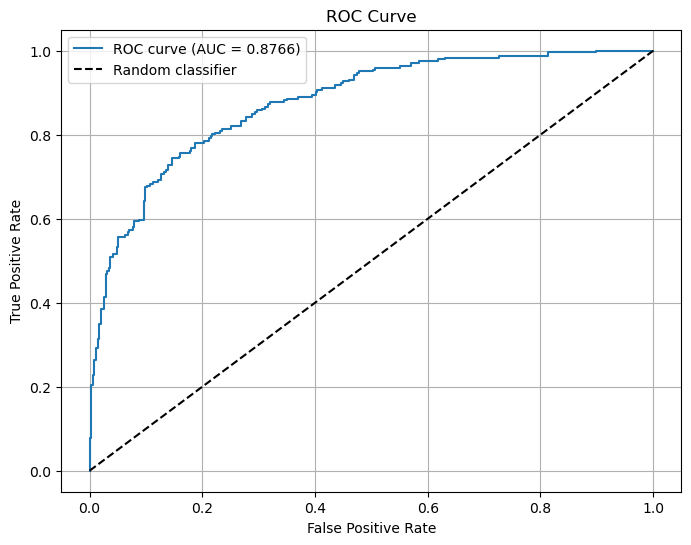

In [127]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [159]:
metrics_list = []
y_test_pred_dummy = dummy_clf.predict(X_test)
y_test_pred_logreg = best_model.predict(X_test)
y_test_proba_dummy = dummy_clf.predict_proba(X_test)
y_test_proba_logreg = best_model.predict_proba(X_test)

def calculate_all_metrics(y_true, y_pred, y_proba, model_name, is_binary=True):
    
    if is_binary:
        avg_method = 'binary'
        roc_auc = roc_auc_score(y_true, y_proba[:, 1])
    else:
        avg_method = 'weighted'
        roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr')
    
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC-AUC': roc_auc,
        'F1-Score': f1_score(y_true, y_pred, average=avg_method, zero_division=0),
        'Precision': precision_score(y_true, y_pred, average=avg_method, zero_division=0),
        'Recall': recall_score(y_true, y_pred, average=avg_method, zero_division=0)
    }

metrics_list.append(calculate_all_metrics(
    y_test, y_test_pred_dummy, y_test_proba_dummy,
    'DummyClassifier'
))

metrics_list.append(calculate_all_metrics(
    y_test, y_test_pred_logreg, y_test_proba_logreg, 
    'LogisticRegression'
))

results_df = pd.DataFrame(metrics_list)
print(results_df)

                Model  Accuracy   ROC-AUC  F1-Score  Precision    Recall
0     DummyClassifier  0.590000  0.500000  0.000000   0.000000  0.000000
1  LogisticRegression  0.801667  0.876648  0.740741   0.798122  0.691057


Бейзлайн всегда выдает наиболле часто встречающийся класс, логистическа регрессия обучается закономерностям. 
Рост показателй:
Accuracy: +0.212 (от 0.590 до 0.802)
ROC-AUC: +0.377 (от 0.500 до 0.877)
ROC-AUC выросла сильнее, это означает, что модель лучше разделяет классы, но ошибки кклассификации все еще встречаются.
При больших С появляется риск переобучения.
Для данной задачи наиболее разумной кажется модель логистической регрессии, так как ее показатели Accuracy и ROC-AUC выше, чем у бейзлайна. Логистическая регрессия быстро обучается и предсказывает данные.